In [ ]:
# 0. Configuration: edit this cell first.
#
# Point the notebook at one SIREN checkpoint, its matching classifier, and a dataset.
# Run this cell before the imports/setup cell below.

MODEL_PATH = "/home/omarg/SIREN_Vista/model_mnist/softlip_L1_lam1e+00_sine_and_readout/modSiren.pth"
CLASSIFIER_PATH = "/home/omarg/SIREN_Vista/runs/softlip_hardcap90_lam1e+00_sine_and_readout/mnist_classifier/best_classifier.pth"

DATASET = "mnist"       # "mnist" or "fmnist"
DATA_ROOT = "/home/omarg/data"
SPLIT = "test"          # "train" or "test"

# GPU. Set before importing torch in the next cell. After this, the selected
# physical GPU is visible to PyTorch as logical cuda:0.
CUDA_DEVICE_ID = 1
DEVICE = "cuda"         # "cuda" or "cpu"

# Inner-loop modulation fitting.
FIT_LR = 0.01

# Random image reconstruction cell.
IMAGE_SEED = 0
RECON_ITERS = [5, 10, 20, 50, 100, 200]

# t-SNE cell.
TSNE_SEED = 0
TSNE_N_SAMPLES = 500
TSNE_FIT_STEPS = 5
TSNE_BATCH_SIZE = 64

# A(x, delta) perturbation cell.
A_SEED = 0
A_N_SAMPLES = 16
A_FIT_STEPS_LIST = [5, 20, 50, 100, 200]
A_EPS_LIST = [1/255, 2/255, 4/255, 8/255, 16/255]
A_BATCH_SIZE = 16

# Model / classifier architecture defaults used if checkpoint metadata is missing.
HIDDEN_DIM = 256
DEPTH = 10
MOD_DIM = 512
CLF_WIDTH = 512
CLF_DEPTH = 3
CLF_DROPOUT = 0.2

print("Configured notebook for:")
print("  model     :", MODEL_PATH)
print("  classifier:", CLASSIFIER_PATH)
print("  dataset   :", DATASET, SPLIT)
print("  device    :", DEVICE, "physical GPU", CUDA_DEVICE_ID if DEVICE == "cuda" else "-")

Configured notebook for:
  model     : /home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth
  classifier: /home/omarg/SIREN_Vista/runs/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/mnist_classifier/best_classifier.pth
  dataset   : mnist test
  device    : cuda physical GPU 1


# Single-Model SIREN Diagnostics

This notebook is meant to be reused for any trained SIREN + classifier pair.

It contains three diagnostics:

1. Pick a random image from the dataset, refit its modulation for several inner-loop budgets, and show the reconstruction + PSNR.
2. Fit modulations for a dataset subset and plot a 2D t-SNE projection of the modulation vectors, colored by labels and classifier predictions.
3. Compute the empirical perturbation amplification metric `A(x, delta)` across inner-loop budgets and perturbation sizes, then show a table and plots.

The first cell is intentionally only paths and knobs. Change that cell to point at a different model.

## 1. Setup

Imports, repo path setup, model loading, dataset loading, and shared fitting helpers. Run this once after editing the configuration cell.

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = str(CUDA_DEVICE_ID)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

REPO_ROOT = Path("/home/omarg/SIREN_Vista")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from SIREN import ModulatedSIREN
from train_classifier import Classifier
from dataloader import get_mnist_loader
from evaluate_reconstruction import batched_forward

if DEVICE == "cuda" and not torch.cuda.is_available():
    print("CUDA requested but unavailable; falling back to CPU")
    DEVICE = "cpu"

print("repo root:", REPO_ROOT)
print("torch:", torch.__version__)
if DEVICE == "cuda":
    print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
    print("logical GPU count:", torch.cuda.device_count())
    print("cuda:0:", torch.cuda.get_device_name(0))
print("device:", DEVICE)

repo root: /home/omarg/SIREN_Vista
torch: 2.0.1+cu117
CUDA_VISIBLE_DEVICES: 1
logical GPU count: 1
cuda:0: NVIDIA GeForce RTX 2080 Ti
device: cuda


In [3]:
def load_siren_checkpoint(path):
    """Load ModulatedSIREN and return (model, checkpoint_dict)."""
    path = Path(path)
    ckpt = torch.load(path, map_location=DEVICE)
    model_args = ckpt.get("model_args", {}) or {}
    hidden_dim = model_args.get("hidden_dim", HIDDEN_DIM)
    depth = model_args.get("depth", DEPTH)
    mod_dim = model_args.get("mod_dim", MOD_DIM)

    model = ModulatedSIREN(
        height=28,
        width=28,
        hidden_features=hidden_dim,
        num_layers=depth,
        modul_features=mod_dim,
        device=DEVICE,
    ).to(DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, ckpt


def load_classifier_checkpoint(path, mod_dim):
    path = Path(path)
    ckpt = torch.load(path, map_location=DEVICE)
    state = ckpt.get("state_dict", ckpt)
    classifier = Classifier(
        width=CLF_WIDTH,
        depth=CLF_DEPTH,
        in_features=mod_dim,
        num_classes=10,
        dropout=CLF_DROPOUT,
    ).to(DEVICE)
    classifier.load_state_dict(state)
    classifier.eval()
    for p in classifier.parameters():
        p.requires_grad_(False)
    return classifier, ckpt


model, model_ckpt = load_siren_checkpoint(MODEL_PATH)
classifier, classifier_ckpt = load_classifier_checkpoint(CLASSIFIER_PATH, model.modul_features)

loader = get_mnist_loader(
    root=DATA_ROOT,
    train=(SPLIT == "train"),
    batch_size=1,
    num_workers=0,
    pin_memory=False,
    fashion=(DATASET == "fmnist"),
)
dataset = loader.dataset

print("Loaded model:")
print("  checkpoint:", MODEL_PATH)
print("  epoch:", model_ckpt.get("epoch"))
print("  loss:", model_ckpt.get("loss"))
print("  variant:", model_ckpt.get("variant"))
print("  variant_args:", model_ckpt.get("variant_args"))
print("  modul_features:", model.modul_features)
print("Loaded classifier:", CLASSIFIER_PATH)
print("Loaded dataset:", DATASET, SPLIT, "n=", len(dataset))

Loaded model:
  checkpoint: /home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth
  epoch: 1
  loss: 0.025990930479218455
  variant: None
  variant_args: None
  modul_features: 512
Loaded classifier: /home/omarg/SIREN_Vista/runs/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/mnist_classifier/best_classifier.pth
Loaded dataset: mnist test n= 10000


/home/omarg/miniforge3/envs/pss/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [4]:
def psnr_from_mse(mse):
    mse = torch.as_tensor(mse).clamp_min(1e-12)
    return 10.0 * torch.log10(1.0 / mse)


def fit_phi_snapshots(model, image_flat, iter_checkpoints, lr=0.01):
    """Fit one modulation vector and save reconstructions at selected steps.

    image_flat: (784,) tensor in [0, 1]
    returns: dict iter -> {phi, fitted_flat, mse, psnr}
    """
    checkpoints = sorted(set(int(x) for x in iter_checkpoints))
    max_iter = max(checkpoints)
    target = image_flat.to(DEVICE).float().view(-1, 1)
    phi = torch.zeros(model.modul_features, device=DEVICE, requires_grad=True)
    opt = optim.SGD([phi], lr=lr)
    snapshots = {}

    for step in range(1, max_iter + 1):
        opt.zero_grad()
        fitted = model(phi)
        loss = ((fitted - target) ** 2).mean()
        loss.backward()
        opt.step()

        if step in checkpoints:
            with torch.no_grad():
                fitted_post = model(phi).detach().view(-1)
                mse = ((fitted_post - image_flat.to(DEVICE).view(-1)) ** 2).mean()
                snapshots[step] = {
                    "phi": phi.detach().clone(),
                    "fitted_flat": fitted_post.detach().clone(),
                    "mse": float(mse.item()),
                    "psnr": float(psnr_from_mse(mse).item()),
                }
    return snapshots


def batched_fit_phi(model, images_flat, steps, lr=0.01, batch_size=None):
    """Fit modulations for a batch of images in parallel.

    images_flat: (B, 784) tensor in [0, 1]
    returns: phi_batch (B, mod_dim), mse_per (B,)
    """
    images_flat = images_flat.to(DEVICE).float()
    B = images_flat.shape[0]
    target = images_flat.view(B, -1, 1)
    phi = torch.zeros(B, model.modul_features, device=DEVICE, requires_grad=True)
    opt = optim.SGD([phi], lr=lr)
    for _ in range(int(steps)):
        opt.zero_grad()
        fitted = batched_forward(model, phi)
        per_image = ((fitted - target) ** 2).mean(dim=(1, 2))
        per_image.sum().backward()
        opt.step()
    with torch.no_grad():
        fitted = batched_forward(model, phi)
        mse = ((fitted - target) ** 2).mean(dim=(1, 2))
    return phi.detach(), mse.detach()


def get_dataset_item(idx):
    image, label = dataset[int(idx)]
    # torchvision returns (1, H, W); keep (H, W)
    image = image.squeeze(0).float()
    return image, int(label)


def collect_random_images(n, seed):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=int(n), replace=False)
    images, labels = [], []
    for idx in idxs:
        image, label = get_dataset_item(idx)
        images.append(image)
        labels.append(label)
    return torch.stack(images, dim=0), torch.tensor(labels, dtype=torch.long), idxs

print("Helpers ready.")

Helpers ready.


## 2. Random Image Reconstruction vs Inner Iterations

This cell uses `IMAGE_SEED` to choose one random image from the configured dataset split. It then refits the modulation vector from zero and saves reconstructions at `RECON_ITERS`.

Outputs:

- A table with MSE and PSNR for every iteration count.
- A plot showing the original image and every reconstruction, with PSNR in each title.

,dataset_index,label,iters,mse,psnr
0,8506,9,5,0.020702,16.839888
1,8506,9,10,0.019247,17.156303
2,8506,9,20,0.017897,17.472208
3,8506,9,50,0.015924,17.979429
4,8506,9,100,0.014733,18.317093
5,8506,9,200,0.013968,18.548735


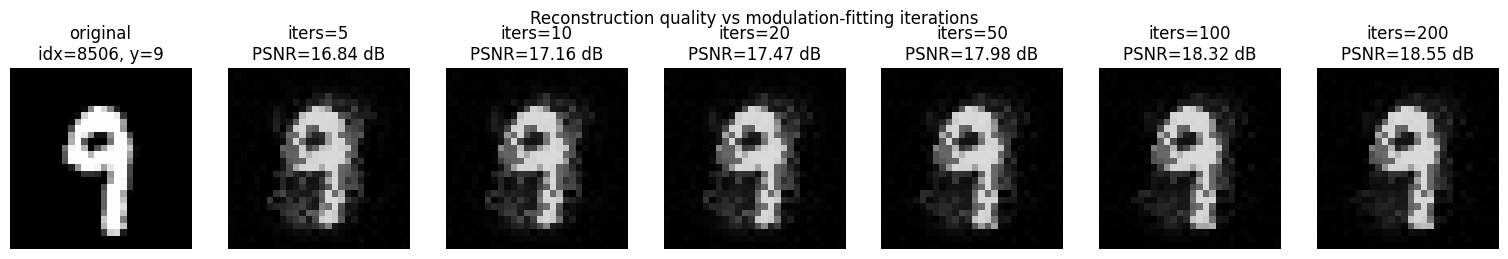

In [5]:
rng = np.random.default_rng(IMAGE_SEED)
image_idx = int(rng.integers(0, len(dataset)))
image, label = get_dataset_item(image_idx)
image_flat = image.view(-1)

snapshots = fit_phi_snapshots(model, image_flat, RECON_ITERS, lr=FIT_LR)

rows = []
for it in sorted(snapshots):
    rows.append({
        "dataset_index": image_idx,
        "label": label,
        "iters": it,
        "mse": snapshots[it]["mse"],
        "psnr": snapshots[it]["psnr"],
    })
recon_df = pd.DataFrame(rows)
display(recon_df)

# Plot original + reconstructions.
n_cols = len(RECON_ITERS) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(2.2 * n_cols, 2.6))
axes[0].imshow(image.cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"original\nidx={image_idx}, y={label}")
axes[0].axis("off")

for ax, it in zip(axes[1:], sorted(snapshots)):
    recon = snapshots[it]["fitted_flat"].view(28, 28).detach().cpu().clamp(0, 1).numpy()
    ax.imshow(recon, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"iters={it}\nPSNR={snapshots[it]['psnr']:.2f} dB")
    ax.axis("off")

fig.suptitle("Reconstruction quality vs modulation-fitting iterations")
plt.tight_layout()
plt.show()

## 3. t-SNE of Fitted Modulation Vectors

This section fits `TSNE_N_SAMPLES` modulation vectors using `TSNE_FIT_STEPS` inner steps, feeds them to the classifier, then projects the modulation vectors to 2D with t-SNE.

The left plot is colored by true label; the right plot is colored by classifier prediction. Wrong predictions are marked with black `x` symbols.

In [6]:
def fit_modulations_for_tsne(n_samples, seed, fit_steps, batch_size):
    images, labels, idxs = collect_random_images(n_samples, seed)
    phis, mses = [], []
    for start in range(0, images.shape[0], batch_size):
        chunk = images[start:start + batch_size].view(-1, 28 * 28)
        phi, mse = batched_fit_phi(model, chunk, steps=fit_steps, lr=FIT_LR)
        phis.append(phi.cpu())
        mses.append(mse.cpu())
    phis = torch.cat(phis, dim=0)
    mses = torch.cat(mses, dim=0)
    return images, labels, idxs, phis, mses

images_tsne, labels_tsne, idxs_tsne, phis_tsne, mses_tsne = fit_modulations_for_tsne(
    TSNE_N_SAMPLES,
    TSNE_SEED,
    TSNE_FIT_STEPS,
    TSNE_BATCH_SIZE,
)

with torch.no_grad():
    logits = classifier(phis_tsne.to(DEVICE))
    pred_tsne = logits.argmax(dim=1).cpu()
    conf_tsne = logits.softmax(dim=1).max(dim=1).values.cpu()

acc = (pred_tsne == labels_tsne).float().mean().item()
print(f"Fitted {len(phis_tsne)} modulations with {TSNE_FIT_STEPS} inner steps")
print(f"Classifier accuracy on this subset: {acc:.4f}")
print(f"Mean reconstruction MSE at {TSNE_FIT_STEPS} steps: {mses_tsne.mean().item():.5f}")

Fitted 500 modulations with 5 inner steps
Classifier accuracy on this subset: 0.9700
Mean reconstruction MSE at 5 steps: 0.02835


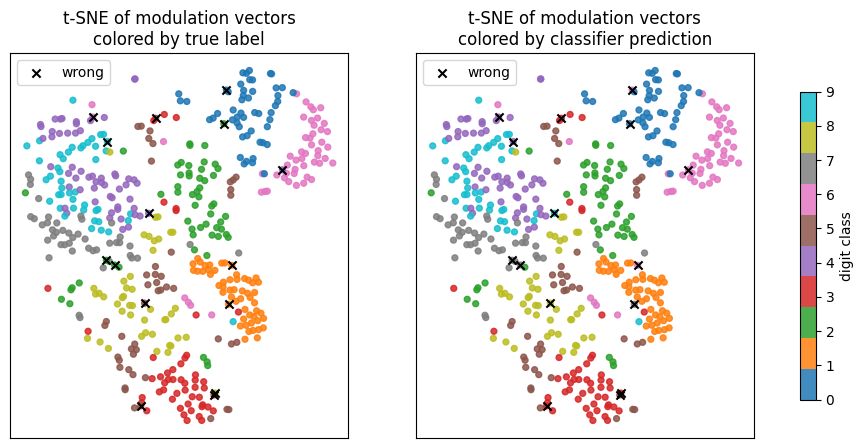

,dataset_index,true_label,pred_label,correct,confidence,mse_fit,z0,z1
0,9527,0,0,True,0.999947,0.035918,22.961823,22.698503
1,8229,1,1,True,0.999997,0.019989,5.017123,-5.900099
2,1453,4,4,True,0.983534,0.021756,-21.518476,9.959575
3,3492,8,8,True,0.998718,0.023102,-10.096405,-10.385283
4,9793,6,6,True,0.999549,0.029890,19.442379,6.885223
5,6225,2,2,True,0.999985,0.040134,4.028929,11.250343
6,9728,4,4,True,0.951837,0.024113,-6.334674,2.982004
7,2132,7,7,True,0.996306,0.021236,-21.465691,0.188336
8,1292,6,6,True,0.991465,0.026979,-1.351439,15.171261
9,6662,7,7,True,0.819926,0.033773,-14.154784,-5.501979


In [7]:
# Compute t-SNE. If sklearn is unavailable, fall back to a simple PCA projection
# so the cell still gives a useful 2D view.
try:
    from sklearn.manifold import TSNE
    projector_name = "t-SNE"
    perplexity = min(30, max(5, (len(phis_tsne) - 1) // 3))
    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=TSNE_SEED,
    ).fit_transform(phis_tsne.numpy())
except Exception as exc:
    print("t-SNE failed or sklearn is unavailable; falling back to PCA.")
    print("Reason:", repr(exc))
    projector_name = "PCA fallback"
    X = phis_tsne.numpy()
    X = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    embedding = X @ Vt[:2].T

wrong = (pred_tsne != labels_tsne).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(embedding[:, 0], embedding[:, 1], c=labels_tsne.numpy(), cmap="tab10", s=18, alpha=0.85)
axes[0].scatter(embedding[wrong, 0], embedding[wrong, 1], marker="x", c="black", s=35, label="wrong")
axes[0].set_title(f"{projector_name} of modulation vectors\ncolored by true label")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].legend(loc="best")

sc1 = axes[1].scatter(embedding[:, 0], embedding[:, 1], c=pred_tsne.numpy(), cmap="tab10", s=18, alpha=0.85)
axes[1].scatter(embedding[wrong, 0], embedding[wrong, 1], marker="x", c="black", s=35, label="wrong")
axes[1].set_title(f"{projector_name} of modulation vectors\ncolored by classifier prediction")
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].legend(loc="best")

cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), ticks=range(10), shrink=0.8)
cbar.set_label("digit class")
plt.show()

tsne_df = pd.DataFrame({
    "dataset_index": idxs_tsne,
    "true_label": labels_tsne.numpy(),
    "pred_label": pred_tsne.numpy(),
    "correct": (pred_tsne == labels_tsne).numpy(),
    "confidence": conf_tsne.numpy(),
    "mse_fit": mses_tsne.numpy(),
    "z0": embedding[:, 0],
    "z1": embedding[:, 1],
})
display(tsne_df.head(20))

## 4. Empirical Perturbation Amplification `A(x, δ)`

This section reproduces the diagnostic idea from `model_diagnostics copy.ipynb`:

```python
A_FIT_STEPS_LIST = [5, 20, 50, 100, 200]
A_EPS_LIST = [1/255, 2/255, 4/255, 8/255, 16/255]
```

For each clean image `x`, noise level `eps`, and fitting budget `k`, we compute:

```text
A(x, δ) = ||phi_k(x + δ) - phi_k(x)||_2 / ||δ||_2
```

where `phi_k` is the modulation fitted from zero for `k` inner-loop SGD steps. Lower `A` means the fitted modulation is less sensitive to the image perturbation.

In [8]:
def compute_A_table(model, n_samples, seed, fit_steps_list, eps_list, batch_size):
    images, labels, idxs = collect_random_images(n_samples, seed)
    images = images.to(DEVICE)
    B = images.shape[0]
    flat_clean = images.view(B, -1)
    gen = torch.Generator(device=DEVICE).manual_seed(seed + 12345)

    rows = []
    for fit_steps in fit_steps_list:
        print(f"Running A(x, delta): fit_steps={fit_steps}")
        phi_clean_all = []
        mse_clean_all = []
        for start in range(0, B, batch_size):
            phi_clean, mse_clean = batched_fit_phi(
                model,
                flat_clean[start:start + batch_size],
                steps=fit_steps,
                lr=FIT_LR,
            )
            phi_clean_all.append(phi_clean)
            mse_clean_all.append(mse_clean)
        phi_clean_all = torch.cat(phi_clean_all, dim=0)
        mse_clean_all = torch.cat(mse_clean_all, dim=0)

        for eps in eps_list:
            delta = (torch.rand(images.shape, generator=gen, device=DEVICE) * 2.0 - 1.0) * float(eps)
            pert = (images + delta).clamp(0, 1)
            flat_pert = pert.view(B, -1)
            delta_flat = (pert - images).view(B, -1)
            delta_norm = delta_flat.norm(dim=1).clamp_min(1e-12)

            phi_pert_all = []
            mse_pert_all = []
            for start in range(0, B, batch_size):
                phi_pert, mse_pert = batched_fit_phi(
                    model,
                    flat_pert[start:start + batch_size],
                    steps=fit_steps,
                    lr=FIT_LR,
                )
                phi_pert_all.append(phi_pert)
                mse_pert_all.append(mse_pert)
            phi_pert_all = torch.cat(phi_pert_all, dim=0)
            mse_pert_all = torch.cat(mse_pert_all, dim=0)

            delta_phi = (phi_pert_all - phi_clean_all).norm(dim=1)
            A = (delta_phi / delta_norm).detach().cpu().numpy()

            rows.append({
                "fit_steps": int(fit_steps),
                "eps": float(eps),
                "eps_255": float(eps * 255),
                "mean_A": float(A.mean()),
                "median_A": float(np.median(A)),
                "std_A": float(A.std()),
                "min_A": float(A.min()),
                "max_A": float(A.max()),
                "mean_||delta||_2": float(delta_norm.mean().item()),
                "mean_||delta_phi||_2": float(delta_phi.mean().item()),
                "mean_mse_clean": float(mse_clean_all.mean().item()),
                "mean_mse_pert": float(mse_pert_all.mean().item()),
            })
    return pd.DataFrame(rows)

A_df = compute_A_table(
    model=model,
    n_samples=A_N_SAMPLES,
    seed=A_SEED,
    fit_steps_list=A_FIT_STEPS_LIST,
    eps_list=A_EPS_LIST,
    batch_size=A_BATCH_SIZE,
)

display(A_df)

Running A(x, delta): fit_steps=5


Running A(x, delta): fit_steps=20
Running A(x, delta): fit_steps=50
Running A(x, delta): fit_steps=100
Running A(x, delta): fit_steps=200


,fit_steps,eps,eps_255,mean_A,median_A,std_A,min_A,max_A,mean_||delta||_2,mean_||delta_phi||_2,mean_mse_clean,mean_mse_pert
0,5,0.003922,1.0,0.003436,0.003333,0.000437,0.002860,0.004322,0.049866,0.000171,0.030902,0.030824
1,5,0.007843,2.0,0.003288,0.003221,0.000346,0.002809,0.004038,0.098241,0.000323,0.030902,0.030783
2,5,0.015686,4.0,0.003358,0.003326,0.000272,0.002883,0.004036,0.195899,0.000658,0.030902,0.030620
3,5,0.031373,8.0,0.003256,0.003235,0.000350,0.002667,0.003946,0.381143,0.001243,0.030902,0.030332
4,5,0.062745,16.0,0.003234,0.003226,0.000308,0.002817,0.003871,0.750477,0.002430,0.030902,0.029705
5,20,0.003922,1.0,0.006423,0.006388,0.000519,0.005795,0.007794,0.049263,0.000317,0.024981,0.024923
6,20,0.007843,2.0,0.009143,0.006408,0.010393,0.006015,0.049369,0.098058,0.000911,0.024981,0.024889
7,20,0.015686,4.0,0.006334,0.006281,0.000320,0.005808,0.007036,0.195758,0.001241,0.024981,0.024723
8,20,0.031373,8.0,0.008759,0.006445,0.005337,0.005871,0.023551,0.382944,0.003335,0.024981,0.024508
9,20,0.062745,16.0,0.007912,0.006881,0.002008,0.006081,0.012971,0.766767,0.006074,0.024981,0.024000


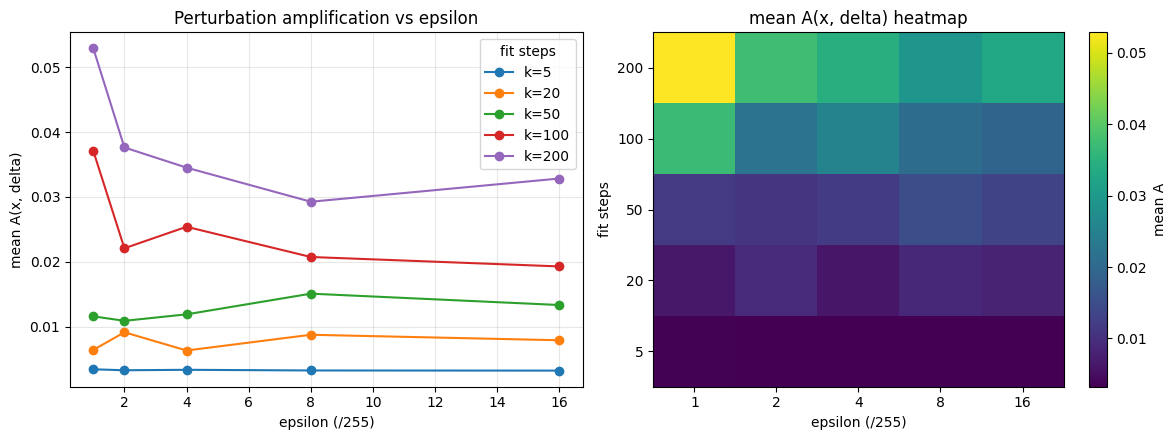

,fit_steps,eps_255,mean_A,median_A,std_A,mean_||delta_phi||_2,mean_mse_clean,mean_mse_pert
0,5,1.0,0.003436,0.003333,0.000437,0.000171,0.030902,0.030824
1,5,2.0,0.003288,0.003221,0.000346,0.000323,0.030902,0.030783
2,5,4.0,0.003358,0.003326,0.000272,0.000658,0.030902,0.030620
3,5,8.0,0.003256,0.003235,0.000350,0.001243,0.030902,0.030332
4,5,16.0,0.003234,0.003226,0.000308,0.002430,0.030902,0.029705
5,20,1.0,0.006423,0.006388,0.000519,0.000317,0.024981,0.024923
6,20,2.0,0.009143,0.006408,0.010393,0.000911,0.024981,0.024889
7,20,4.0,0.006334,0.006281,0.000320,0.001241,0.024981,0.024723
8,20,8.0,0.008759,0.006445,0.005337,0.003335,0.024981,0.024508
9,20,16.0,0.007912,0.006881,0.002008,0.006074,0.024981,0.024000


In [9]:
# Plots for A(x, delta).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for fit_steps, group in A_df.groupby("fit_steps"):
    group = group.sort_values("eps_255")
    axes[0].plot(group["eps_255"], group["mean_A"], marker="o", label=f"k={fit_steps}")
axes[0].set_xlabel("epsilon (/255)")
axes[0].set_ylabel("mean A(x, delta)")
axes[0].set_title("Perturbation amplification vs epsilon")
axes[0].grid(alpha=0.3)
axes[0].legend(title="fit steps")

heat = A_df.pivot(index="fit_steps", columns="eps_255", values="mean_A")
im = axes[1].imshow(heat.values, aspect="auto", origin="lower")
axes[1].set_xticks(range(len(heat.columns)))
axes[1].set_xticklabels([f"{c:g}" for c in heat.columns])
axes[1].set_yticks(range(len(heat.index)))
axes[1].set_yticklabels([str(i) for i in heat.index])
axes[1].set_xlabel("epsilon (/255)")
axes[1].set_ylabel("fit steps")
axes[1].set_title("mean A(x, delta) heatmap")
fig.colorbar(im, ax=axes[1], label="mean A")

plt.tight_layout()
plt.show()

# Optional compact table for report copy/paste.
compact = A_df[["fit_steps", "eps_255", "mean_A", "median_A", "std_A", "mean_||delta_phi||_2", "mean_mse_clean", "mean_mse_pert"]]
display(compact)